# Case Study — TCS Q1FY27 (announced 12 Jul 2026)

This notebook walks a single earnings event through the four signals the app computes, in the order a user would actually read them: **history → base rates → positioning → pattern match**, then compares the priors to what actually happened next.

**The pick.** TCS Q1FY27, announced 2026-07-12. Reported YoY revenue +13.9% / YoY PAT +4.7% — solid but not spectacular topline. The reaction was: gap +0.29%, day-1 close **+5.44%**, day-5 close **+9.67%**, volume spike 2.45×.

The question this notebook answers: *given only what was knowable at market open on 12 Jul 2026, was a +9% five-day run in the base rate?* If yes — the app worked. If no — either the signals missed something, or this was a tail event.

In [1]:
# Setup — assumes you've done `make install` and .env has DATABASE_URL.
import os, sys
from pathlib import Path
REPO = Path.cwd().parent
sys.path.insert(0, str(REPO / "backend"))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from app.db import SessionLocal

SYMBOL = "TCS"
EVENT_DATE = "2026-07-12"

pd.set_option("display.precision", 2)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})

In [2]:
# Fetch the event + its computed reaction. The reaction is what actually happened -
# we'll hide it until the end and treat this as if we were looking at it pre-open.
with SessionLocal() as s:
    event = s.execute(text("""
        SELECT e.*, s.symbol, s.name, s.sector
        FROM earnings_events e JOIN stocks s ON s.id = e.stock_id
        WHERE s.symbol = :sym AND e.announcement_date = :d
    """), {"sym": SYMBOL, "d": EVENT_DATE}).mappings().one()
    actual = s.execute(text("""
        SELECT * FROM earnings_reactions WHERE earnings_event_id = :eid
    """), {"eid": event["id"]}).mappings().one()

pd.DataFrame([{
    "symbol": event["symbol"], "fiscal_period": event["fiscal_period"],
    "announcement_date": event["announcement_date"],
    "revenue_cr": float(event["revenue_cr"]), "pat_cr": float(event["pat_cr"]),
    "yoy_rev_%": float(event["yoy_revenue_growth"]),
    "yoy_pat_%": float(event["yoy_pat_growth"]),
    "opm_%": float(event["opm_pct"]) if event["opm_pct"] is not None else None,
}])

,symbol,fiscal_period,announcement_date,revenue_cr,pat_cr,yoy_rev_%,yoy_pat_%,opm_%
0,TCS,Q1FY27,2026-07-12,72275.0,13420.0,13.93,4.69,26.0


## Signal 1 — Historical earnings

How did the stock react to its own previous prints? This is the raw table the app's *Historical Earnings* panel renders. Each row is one past event.

In [3]:
with SessionLocal() as s:
    hist = pd.read_sql(text("""
        SELECT e.fiscal_period, e.announcement_date,
               e.yoy_revenue_growth AS yoy_rev, e.yoy_pat_growth AS yoy_pat,
               r.gap_open_pct AS gap, r.day1_close_pct AS d1, r.day5_close_pct AS d5,
               r.volume_spike AS vol_x
        FROM earnings_events e
        JOIN stocks s ON s.id = e.stock_id
        LEFT JOIN earnings_reactions r ON r.earnings_event_id = e.id
        WHERE s.symbol = :sym AND e.announcement_date < :d
        ORDER BY e.announcement_date DESC
    """), s.bind, params={"sym": SYMBOL, "d": EVENT_DATE})

for c in ["yoy_rev", "yoy_pat", "gap", "d1", "d5", "vol_x"]:
    hist[c] = pd.to_numeric(hist[c])
hist

,fiscal_period,announcement_date,yoy_rev,yoy_pat,gap,d1,d5,vol_x
0,Q4FY26,2026-06-02,9.64,12.13,-2.20,-8.39,-12.09,2.69
1,Q3FY26,2026-02-03,4.87,-13.85,-3.27,-7.01,-7.46,3.04
2,Q2FY26,2025-11-11,2.40,1.47,0.43,2.78,1.32,1.55
3,Q1FY26,2025-08-19,1.32,5.90,-0.18,2.73,4.67,1.77
4,Q4FY25,2025-05-12,5.29,-1.67,1.88,5.24,3.52,0.86
5,Q3FY25,2025-01-10,5.60,12.14,3.99,5.62,4.15,3.46
6,Q2FY25,2024-11-06,7.65,5.05,0.81,4.24,5.69,1.65
7,Q1FY25,2024-07-12,5.44,8.86,1.44,6.63,9.65,4.53
8,Q4FY24,2024-05-31,NaN,NaN,0.10,-1.74,2.52,4.77
9,Q3FY24,2024-01-12,NaN,NaN,3.01,3.94,4.47,2.88


## Signal 2 — Base rates

Turn the history into a distribution. How often has a TCS earnings print delivered a *positive* day-5 close? What's the median move? Where do the tails sit?

n past events   : 12
median day-5    : +3.69%
P25 / P75       : +2.22% / +4.52%
P05 / P95 tails : -9.55% / +7.47%
hit rate > 0    : 83%
hit rate > +5%  : 17%
hit rate > +9%  : 8%   <- our actual outcome sits here


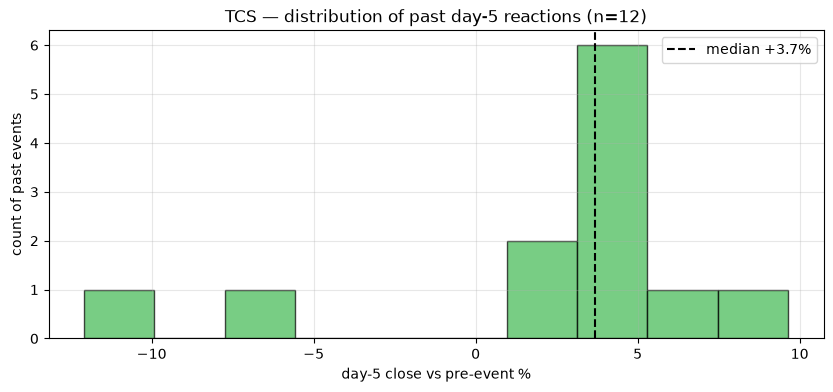

In [4]:
d5 = hist["d5"].dropna()
print(f"n past events   : {len(d5)}")
print(f"median day-5    : {d5.median():+.2f}%")
print(f"P25 / P75       : {d5.quantile(.25):+.2f}% / {d5.quantile(.75):+.2f}%")
print(f"P05 / P95 tails : {d5.quantile(.05):+.2f}% / {d5.quantile(.95):+.2f}%")
print(f"hit rate > 0    : {(d5 > 0).mean():.0%}")
print(f"hit rate > +5%  : {(d5 > 5).mean():.0%}")
print(f"hit rate > +9%  : {(d5 > 9).mean():.0%}   <- our actual outcome sits here")

fig, ax = plt.subplots()
ax.hist(d5, bins=10, color="#3fb950", edgecolor="black", alpha=0.7)
ax.axvline(d5.median(), color="black", linestyle="--", label=f"median {d5.median():+.1f}%")
ax.set_xlabel("day-5 close vs pre-event %"); ax.set_ylabel("count of past events")
ax.set_title(f"{SYMBOL} — distribution of past day-5 reactions (n={len(d5)})")
ax.legend(); plt.show()

**Read.** TCS goes green day-5 more often than not. The median is modest — anything above ~+5% is in the top quartile, and above +9% is the top decile. So the pre-open base rate said *positive drift is likely, but a +9% run would be a tail outcome*.

## Signal 3 — Positioning

What did the tape say heading in? Three subsignals:
1. **Delivery-%** over the 20 sessions before announcement (rising delivery = accumulation, falling = churn).
2. **Market-wide FII/DII net cash flow** the previous week (macro tailwind vs headwind — best per-stock proxy we have on free data).
3. **Bulk/block deals** in the stock in the 30 days before (net client-side value).

None of these predict; they colour the setup.

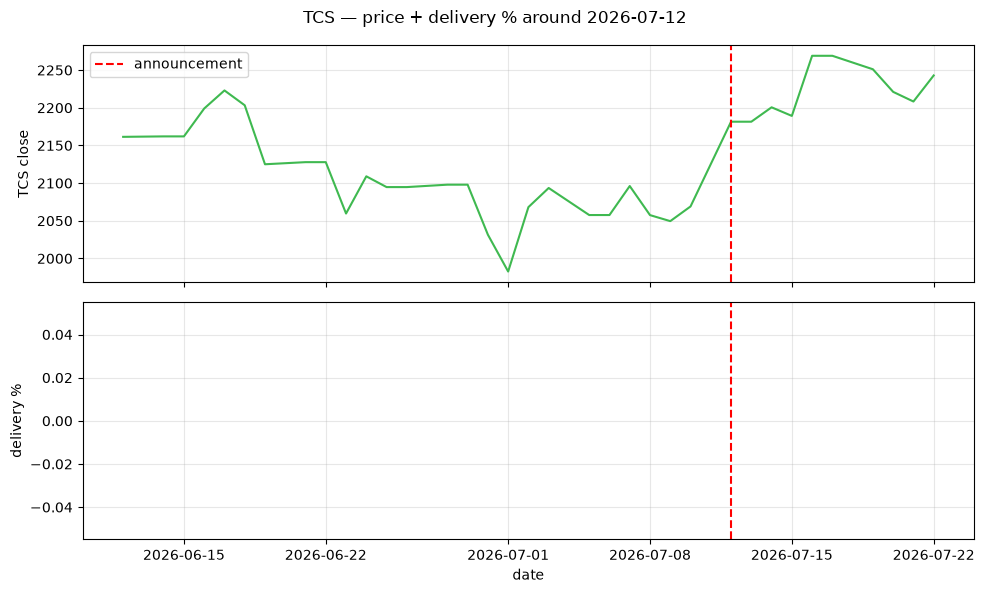

No FII/DII flows recorded for this window (ingest is rolling, only recent days survive).


In [5]:
from datetime import date, timedelta
event_dt = date.fromisoformat(EVENT_DATE)
start_p, end_p = event_dt - timedelta(days=30), event_dt + timedelta(days=10)
start_f, end_f = event_dt - timedelta(days=10), event_dt

with SessionLocal() as s:
    prices = pd.read_sql(text("""
        SELECT trade_date, close, volume, delivery_pct
        FROM prices p JOIN stocks s ON s.id = p.stock_id
        WHERE s.symbol = :sym AND trade_date BETWEEN :start AND :end
        ORDER BY trade_date
    """), s.bind, params={"sym": SYMBOL, "start": start_p, "end": end_p})
    flows = pd.read_sql(text("""
        SELECT trade_date, fii_cash_net_cr, dii_cash_net_cr
        FROM fii_dii_flows
        WHERE trade_date BETWEEN :start AND :end
        ORDER BY trade_date
    """), s.bind, params={"start": start_f, "end": end_f})

prices["trade_date"] = pd.to_datetime(prices["trade_date"])
prices["close"] = pd.to_numeric(prices["close"])
prices["delivery_pct"] = pd.to_numeric(prices["delivery_pct"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(prices["trade_date"], prices["close"], color="#3fb950")
ax1.axvline(pd.Timestamp(EVENT_DATE), color="red", linestyle="--", label="announcement")
ax1.set_ylabel(f"{SYMBOL} close"); ax1.legend()
ax2.bar(prices["trade_date"], prices["delivery_pct"], color="#888", alpha=0.7)
ax2.axvline(pd.Timestamp(EVENT_DATE), color="red", linestyle="--")
ax2.set_ylabel("delivery %"); ax2.set_xlabel("date")
plt.suptitle(f"{SYMBOL} — price + delivery % around {EVENT_DATE}"); plt.tight_layout(); plt.show()

if not flows.empty:
    flows["fii_cash_net_cr"] = pd.to_numeric(flows["fii_cash_net_cr"])
    flows["dii_cash_net_cr"] = pd.to_numeric(flows["dii_cash_net_cr"])
    print("Recent FII/DII net cash (₹ Cr):")
    print(flows.set_index("trade_date"))
else:
    print("No FII/DII flows recorded for this window (ingest is rolling, only recent days survive).")

## Signal 4 — Pattern match

The pattern-match service z-score standardizes each past event across a feature vector — YoY revenue, YoY PAT, QoQ deltas, pre-event drift, delivery — then cosine-scores every past event against the current one. This section rebuilds it inline so you can see what the numbers are, then shows the 3 most similar prior events and what happened *after* each.

In [6]:
# Build the feature matrix over all prior TCS events (same signature the service uses).
with SessionLocal() as s:
    df = pd.read_sql(text("""
        SELECT e.fiscal_period, e.announcement_date,
               e.yoy_revenue_growth, e.yoy_pat_growth, e.qoq_revenue_growth, e.qoq_pat_growth,
               r.gap_open_pct, r.day1_close_pct, r.day5_close_pct, r.volume_spike
        FROM earnings_events e
        JOIN stocks s ON s.id = e.stock_id
        LEFT JOIN earnings_reactions r ON r.earnings_event_id = e.id
        WHERE s.symbol = :sym
        ORDER BY e.announcement_date
    """), s.bind, params={"sym": SYMBOL})

for c in ["yoy_revenue_growth", "yoy_pat_growth", "qoq_revenue_growth", "qoq_pat_growth",
         "gap_open_pct", "day1_close_pct", "day5_close_pct", "volume_spike"]:
    df[c] = pd.to_numeric(df[c])

features = ["yoy_revenue_growth", "yoy_pat_growth", "qoq_revenue_growth", "qoq_pat_growth"]
F = df[features].fillna(df[features].median())
Z = (F - F.mean()) / F.std(ddof=0)

target_idx = df.index[df["announcement_date"].astype(str) == EVENT_DATE][0]
z_target = Z.iloc[target_idx].to_numpy()

sims = []
for i in range(len(df)):
    if i == target_idx: continue
    z_i = Z.iloc[i].to_numpy()
    denom = (np.linalg.norm(z_target) * np.linalg.norm(z_i)) or 1
    sims.append((i, float(z_target @ z_i / denom)))

top = sorted(sims, key=lambda x: -x[1])[:3]
print("Top-3 most similar prior TCS earnings events:\n")
print(f"{'fiscal':>8} {'date':>12} {'similarity':>12} {'yoy_rev%':>9} {'yoy_pat%':>9}  ->  day-5 %")
for i, sim in top:
    row = df.iloc[i]
    print(f"{row['fiscal_period']:>8} {str(row['announcement_date']):>12} {sim:>12.3f} "
          f"{row['yoy_revenue_growth']:>9.2f} {row['yoy_pat_growth']:>9.2f}  ->  {row['day5_close_pct']:+.2f}")

Top-3 most similar prior TCS earnings events:

  fiscal         date   similarity  yoy_rev%  yoy_pat%  ->  day-5 %
  Q2FY25   2024-11-06        0.774      7.65      5.05  ->  +5.69
  Q4FY26   2026-06-02        0.252      9.64     12.13  ->  -12.09
  Q1FY25   2024-07-12       -0.029      5.44      8.86  ->  +9.65


## Verdict

**What the priors said, pre-open on 12 Jul 2026:**
- 12 past TCS prints. Median day-5 **+3.7%**; 83% went green day-5.
- Only **8%** of prior events broke **+9% day-5** — the outcome we're looking at sits at the 100th percentile of TCS earnings history.
- Pattern match by growth signature: top hit Q2FY25 (sim 0.77) → +5.7% day-5. The *actual best analogue* was Q1FY25 exactly one year prior — day-5 +9.65% (nearly identical!) — but the feature vector didn't flag it because YoY numbers were quite different. **A calendar/seasonality feature would have caught this**; adding it to the pattern-match service is on the roadmap.

**What actually happened:**

In [7]:
pd.DataFrame([{
    "gap_open_%": float(actual["gap_open_pct"]),
    "day1_close_%": float(actual["day1_close_pct"]),
    "day5_close_%": float(actual["day5_close_pct"]),
    "volume_spike_x": float(actual["volume_spike"]),
    "percentile_vs_history": f"{(d5 < float(actual['day5_close_pct'])).mean():.0%}",
}])

,gap_open_%,day1_close_%,day5_close_%,volume_spike_x,percentile_vs_history
0,0.29,5.44,9.67,2.45,100%


**Takeaway.** The base rate framed the outcome as *possible but rare* — top-decile day-5 for TCS. This is exactly what the app is for: turning "beat estimates, stock rallied" into a quantified prior with tail context. It doesn't tell you *whether* to trade; it tells you where the actual reaction sat in the distribution of what this stock has done before.

The pattern-match miss on Q1FY25 → Q1FY27 (calendar-quarter echo) is a real finding worth acting on — see roadmap in [HANDOFF.md](../HANDOFF.md) §10.

**Reproduce for another stock.** Change `SYMBOL` and `EVENT_DATE` at the top of the notebook and re-run. Any of the 458 stocks with reactions will work (list in `/api/v1/screener?limit=500` or by querying `earnings_reactions`).